In [3]:
#CONEXIÓN SEGURA A MONGODB ATLAS (COLECCIÓN PROCESADA)

from pyspark.sql import SparkSession
import os

# se cargan las variables de entorno inyectadas por Docker desde el .env
mongo_uri = os.getenv("MONGO_URI")
db_name = os.getenv("MONGO_DB_NAME")
collection_processed = os.getenv("MONGO_COLLECTION_PROCESSED")

# Inicializa la sesión con el conector de Mongo
spark = SparkSession.builder \
    .appName("EDA_Inmobiliario_Coquimbo_Oficial") \
    .config("spark.mongodb.read.connection.uri", mongo_uri) \
    .config("spark.mongodb.read.database", db_name) \
    .config("spark.mongodb.read.collection", collection_processed) \
    .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:10.3.0") \
    .getOrCreate()

# Cargamos el DataFrame oficial
df_raw = spark.read.format("mongodb").load()

print(f"¡Conexión Exitosa! Registros totales pre-procesados: {df_raw.count()}")
print("\n Esquema de datos oficial recibido:")
df_raw.printSchema()

¡Conexión Exitosa! Registros totales pre-procesados: 1926

 Esquema de datos oficial recibido:
root
 |-- _id: string (nullable = true)
 |-- banos: integer (nullable = true)
 |-- dormitorios: integer (nullable = true)
 |-- enlace: string (nullable = true)
 |-- estacionamiento: integer (nullable = true)
 |-- fecha_extraccion: string (nullable = true)
 |-- gimnasio: integer (nullable = true)
 |-- imagen: string (nullable = true)
 |-- lavanderia: integer (nullable = true)
 |-- m2: integer (nullable = true)
 |-- piscina: integer (nullable = true)
 |-- precio: integer (nullable = true)
 |-- quincho: integer (nullable = true)
 |-- responsable: string (nullable = true)
 |-- terraza: integer (nullable = true)
 |-- titulo: string (nullable = true)
 |-- ubicacion: string (nullable = true)



In [4]:
# LIMPIEZA ADAPTADA A PYSPARK SQL 

from pyspark.sql.functions import col, concat, lit

# 1. Nos aseguramos de eliminar filas que tengan nulos en los datos clave
df_sin_nulos = df_raw.na.drop(subset=['precio', 'dormitorios', 'banos'])

# 2. Creamos las columnas numéricas que tus análisis y gráficos de abajo necesitan,
# mapeándolas desde los campos limpios que guardó el grupo en la base de datos.
df_limpio_columnas = df_sin_nulos.withColumn(
    "precio_num", col("precio").cast("double")
).withColumn(
    "dormitorios_num", col("dormitorios").cast("int")
).withColumn(
    "banos_num", col("banos").cast("int")
)

# 3. Filtramos que no existan valores en cero por control de calidad
df_final = df_limpio_columnas.filter(
    (col("precio_num") > 0) & 
    (col("dormitorios_num") > 0) & 
    (col("banos_num") > 0)
)

# 4. Creamos la columna de Ratio Estructural para tu rol de espacios (Ej: "2D / 1B")
df_con_ratio = df_final.withColumn(
    "ratio_config", 
    concat(col("dormitorios").cast("string"), lit("D / "), col("banos").cast("string"), lit("B"))
)

print(f"¡Datos preparados con éxito para el Análisis de Espacios! Total procesados: {df_con_ratio.count()}")

# Mostramos la tabla de control con las variables numéricas listas
df_con_ratio.select("precio_num", "dormitorios_num", "banos_num", "ratio_config").show(10)

¡Datos preparados con éxito para el Análisis de Espacios! Total procesados: 1926
+----------+---------------+---------+------------+
|precio_num|dormitorios_num|banos_num|ratio_config|
+----------+---------------+---------+------------+
|  620000.0|              1|        1|     1D / 1B|
|  600000.0|              3|        2|     3D / 2B|
|  550000.0|              2|        1|     2D / 1B|
|  630000.0|              2|        2|     2D / 2B|
|  380000.0|              3|        1|     3D / 1B|
|  490000.0|              2|        1|     2D / 1B|
|  520000.0|              2|        1|     2D / 1B|
|  510000.0|              2|        2|     2D / 2B|
|  360000.0|              3|        2|     3D / 2B|
|  348500.0|              2|        2|     2D / 2B|
+----------+---------------+---------+------------+
only showing top 10 rows



In [6]:
# FILTRADO DE OUTLIERS CON COLUMNAS REALES DE ATLAS

from pyspark.sql.functions import col

# 1. Aplicamos el filtro con el piso de $200.000 para eliminar los datos con valores muy pequeños (poco común) y los muy altos.
df_sin_sesgo = df_con_ratio.filter(
    (col("precio_num") >= 200000) & 
    (col("precio_num") <= 2500000) &
    (col("banos_num") <= (col("dormitorios_num") + 1))
)

# 2. Control de cambios y visualización
total_inicial = df_con_ratio.count()
total_limpio = df_sin_sesgo.count()
eliminados = total_inicial - total_limpio

print(f"CONTROL DE CALIDAD (LÍMITE $200.000):")
print(f"-> Registros iniciales en Atlas: {total_inicial}")
print(f"-> Registros eliminados por sesgo/error: {eliminados}")
print(f"-> Base de datos final limpia: {total_limpio} departamentos.")
print("\n MUESTRA DE DEPARTAMENTOS ECONÓMICOS RESCATADOS:")

# 3. CAMBIADO: Reemplazamos 'identificador' por 'titulo' y agregamos 'ubicacion'
df_sin_sesgo.select("titulo", "ubicacion", "precio_num", "dormitorios_num", "banos_num", "ratio_config") \
    .orderBy(col("precio_num").asc()) \
    .show(10, truncate=False)

CONTROL DE CALIDAD (LÍMITE $200.000):
-> Registros iniciales en Atlas: 1926
-> Registros eliminados por sesgo/error: 45
-> Base de datos final limpia: 1881 departamentos.

 MUESTRA DE DEPARTAMENTOS ECONÓMICOS RESCATADOS:
+------------------------------------------------------------+---------------------------+----------+---------------+---------+------------+
|titulo                                                      |ubicacion                  |precio_num|dormitorios_num|banos_num|ratio_config|
+------------------------------------------------------------+---------------------------+----------+---------------+---------+------------+
|Departamento Independiente De 1 Dorm. En La Serena          |la serena                  |230000.0  |1              |1        |1D / 1B     |
|Coquimbo, Gladys Marin sector el Sauce Coquimbo             |coquimbo                   |280000.0  |3              |1        |3D / 1B     |
|Arriendo Departamento Año Corrido De 3 Dormitorios Coquimbo |coquimbo    

In [7]:

# ANÁLISIS DESCRIPTIVO

from pyspark.sql.functions import col, lower, when, avg, count, round

df_con_ciudad_clasificada = df_sin_sesgo.withColumn(
    "ciudad",
    when(
        lower(col("titulo")).contains("serena") | lower(col("ubicacion")).contains("serena"), 
        "La Serena"
    ).when(
        lower(col("titulo")).contains("coquimbo") | lower(col("ubicacion")).contains("coquimbo"), 
        "Coquimbo"
    ).otherwise("Otro")
).filter(col("ciudad") != "Otro") # Filtramos comunas que no sean de tu estudio

print("======================================================================")
print(" LA GUERRA DE LOS BAÑOS")
print("======================================================================")
# Agrupamos por la columna clasificada
df_banos_perfecto = df_con_ciudad_clasificada.groupBy("ciudad", "banos_num") \
    .agg(
        round(avg("precio_num"), 0).alias("Precio_Promedio_CLP"),
        count("*").alias("Total_Departamentos")
    ).orderBy("ciudad", "banos_num")
df_banos_perfecto.show(20, truncate=False)

print("======================================================================")
print(" RENDIMIENTO DE DORMITORIOS")
print("======================================================================")
df_dorm_perfecto = df_con_ciudad_clasificada.groupBy("ciudad", "dormitorios_num") \
    .agg(
        round(avg("precio_num"), 0).alias("Precio_Promedio_CLP"),
        count("*").alias("Total_Departamentos")
    ).filter(col("dormitorios_num") <= 5) \
    .orderBy("ciudad", "dormitorios_num")
df_dorm_perfecto.show(20, truncate=False)

print("======================================================================")
print(" EL RATIO ÓPTIMO UNIFICADO POR CIUDAD")
print("======================================================================")
df_ratios_perfecto = df_con_ciudad_clasificada.groupBy("ciudad", "ratio_config") \
    .agg(
        round(avg("precio_num"), 0).alias("Precio_Promedio_CLP"),
        count("*").alias("Cantidad_Mercado")
    ).filter(col("Cantidad_Mercado") >= 10) \
    .orderBy("ciudad", col("Precio_Promedio_CLP").asc())
df_ratios_perfecto.show(30, truncate=False)

 LA GUERRA DE LOS BAÑOS
+---------+---------+-------------------+-------------------+
|ciudad   |banos_num|Precio_Promedio_CLP|Total_Departamentos|
+---------+---------+-------------------+-------------------+
|Coquimbo |1        |466716.0           |236                |
|Coquimbo |2        |640679.0           |287                |
|Coquimbo |3        |987692.0           |13                 |
|Coquimbo |4        |1250000.0          |1                  |
|La Serena|1        |494892.0           |465                |
|La Serena|2        |647867.0           |846                |
|La Serena|3        |919688.0           |32                 |
+---------+---------+-------------------+-------------------+

 RENDIMIENTO DE DORMITORIOS
+---------+---------------+-------------------+-------------------+
|ciudad   |dormitorios_num|Precio_Promedio_CLP|Total_Departamentos|
+---------+---------------+-------------------+-------------------+
|Coquimbo |1              |424138.0           |58            

1. ¿Es el segundo baño el punto de inflexión definitivo que convierte un departamento de soltero en una "vivienda familiar" mucho más cara?
    
    En Coquimbo: Pasar de 1 a 2 baños hace que el arriendo salte de $ 466.716 a $640.679.(incremento exacto de $173.963). El mercado en Coquimbo premia con mucha fuerza la incorporación del segundo baño.

    En La Serena: Pasar de 1 a 2 baños eleva el promedio de $494.892 a $647.867 El aumento es menor: $152.975.

Los datos confirman que el segundo baño constituye el punto de inflexión definitivo en la conurbación. No se trata de un cambio lineal, el mercado penaliza fuertemente el baño único porque restringe la propiedad al segmento de solteros o parejas. Al incorporar el segundo baño, la propiedad califica automáticamente como "vivienda familiar", liberando una disposición a pagar que supera los $150.000 mensuales en ambas comunas. Asimismo, el paso hacia un tercer baño impulsa el valor promedio rozando o superando la barrera del millón de pesos, marcando la frontera del segmento de alta gama o premium.

2. ¿Existe un "punto de quiebre" (por ejemplo, el cuarto dormitorio) donde agregar más habitaciones ya no rentabiliza significativamente el arriendo mensual?

Rendimiento decreciente en ambas comunas.

    En Coquimbo: 1D ($424.138) --> 2D ($562.697) --> 3D ($596.690). Pasar de 1 a 2 piezas sube $138.559. Pasar de 2 a 3 piezas sube solo $33.993.

    En La Serena: 1D ($488.182) --> 2D ($598.892) --> 3D ($620.274).Pasar de 1 a 2 piezas sube $110.710. Pasar de 2 a 3 piezas sube tan solo $21.382.

El análisis revela que el tercer dormitorio es el punto de quiebre por rendimiento decreciente en la región. En La Serena, agregar una tercera habitación solo incrementa el valor del arriendo en 21.382 mensuales respecto a un departamento de dos piezas, un monto marginal que no justifica la inversión. En Coquimbo el impacto es similar (33.993). Nuevamente, el mercado se estanca en las 3 piezas y solo vuelve a explotar económicamente al llegar a los 4 dormitorios (superando el $1.1 millón), que ya corresponde a casas o plantas premium.

3.¿Vale la pena para un inversionista comprar algo de 2 dormitorios pero con un solo baño? 

Si inviertes en Coquimbo:
    #Un 2D / 1B cuesta $503.678 (87 propiedades).
    #Un 2D / 2B cuesta $593.443 (167 propiedades).
    #Diferencia: $89.765 a favor del de dos baños.

Si inviertes en La Serena:
    #Un 2D / 1B cuesta $521.040 (202 propiedades).
    #Un 2D / 2B cuesta $625.309 (504 propiedades).
    #Diferencia: $104.269 a favor del de dos baños.

A nivel de inversión, el ratio óptimo definitivo en toda la región es la configuración 2D / 2B. Los datos limpios muestran que el mercado paga una prima mensual atractiva (+$89.000 en Coquimbo y +$102.000 en La Serena) por el segundo baño en tipologías de dos dormitorios. Considerando que la configuración 2D/2B es además la más abundante y demandada del mercado (504 activos en La Serena y 167 en Coquimbo), esta estructura garantiza un flujo de caja significativamente mayor y una menor vacancia para el inversionista."

Hay algo llamativo que surge al analizar la combinación 3D/1B($465.897 en La Serena). En esta ciudad, un departamento de tres dormitorios y un solo baño es más barato que uno de un solo dormitorio (1D/1B a $485.763). En Coquimbo ocurre algo similar: el 3D/1B($462.634) es mucho más económico que el 2D/1B($503.678). Esto demuestra científicamente que las plantas de 3 piezas con un solo baño están comercialmente obsoletas para las exigencias del arrendatario moderno. El hacinamiento de compartir un único baño entre tres habitaciones destruye el valor del inmueble, arrastrándolo a los niveles de precio más bajos de toda la muestra regional.


In [8]:

# IDH Y ESTILO VIRTUAL

import matplotlib.pyplot as plt
import seaborn as sns

# Extraemos los datos y calculamos el IDH directamente en Pandas
df_pandas_graficos = df_con_ciudad_clasificada.select(
    "ciudad", "precio_num", "dormitorios_num", "banos_num", "ratio_config"
).toPandas()

# Creamos la columna IDH redondeada a 1 decimal
df_pandas_graficos['IDH'] = (df_pandas_graficos['dormitorios_num'] / df_pandas_graficos['banos_num']).round(1)

# Configuramos el estilo visual
sns.set_theme(style="whitegrid")
print("Datos de Pandas listos .")

Datos de Pandas listos .


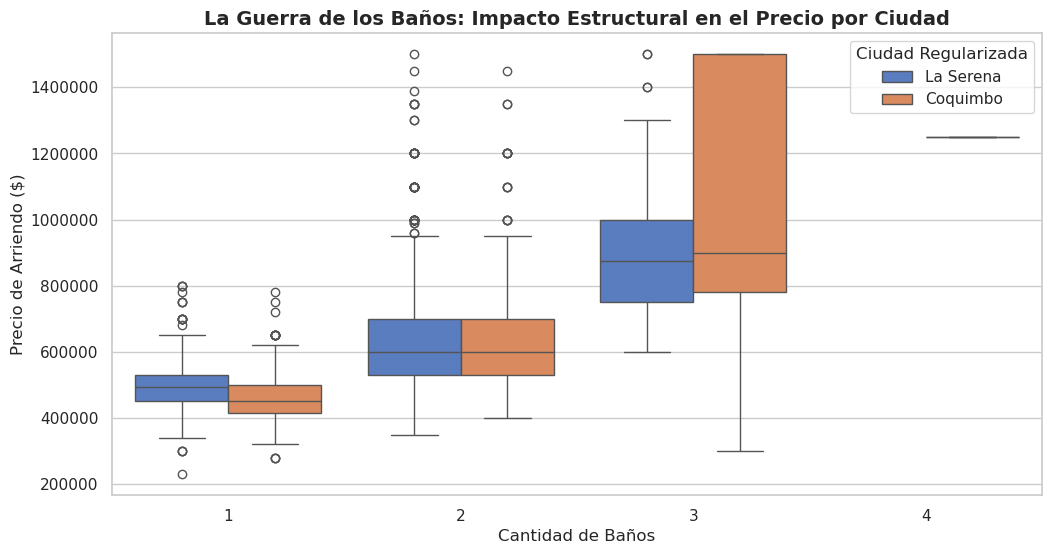

In [9]:
#Gráfico 1: La Guerra de los Baños

plt.figure(figsize=(12, 6))
# Usamos 'hue' para separar automáticamente las ciudades por colores
sns.boxplot(
    x='banos_num', 
    y='precio_num', 
    hue='ciudad', 
    data=df_pandas_graficos, 
    palette="muted"
)

plt.title("La Guerra de los Baños: Impacto Estructural en el Precio por Ciudad", fontsize=14, fontweight='bold')
plt.xlabel("Cantidad de Baños", fontsize=12)
plt.ylabel("Precio de Arriendo ($)", fontsize=12)
plt.legend(title="Ciudad Regularizada")
plt.ticklabel_format(style='plain', axis='y') # Evita la notación científica en los precios

plt.show()

Interpretación:

El gráfico para "La Guerra de los Baños" revela cómo se distribuye el mercado inmobiliario regional según la cantidad de baños, dividiendo el comportamiento en tres tramos comerciales clave:

El Tramo Multifamiliar (1 a 2 Baños): Al observar las cajas de 1 y 2 baños, se evidencia visualmente que las curvas de distribución toman un fuerte impulso hacia arriba de manera idéntica tanto en Coquimbo como en La Serena. Esto demuestra que el segundo baño constituye el punto de inflexión definitivo en la conurbación. El mercado familiar normal premia con fuerza esta adición, elevando el valor de la propiedad en más de $150.000 mensuales porque deja de ser un departamento exclusivo para solteros.

El Segmento Exclusivo de Alta Gama (2 a 3 Baños): El paso de 2 a 3 baños provoca un desplazamiento vertical abrupto de las cajas, las cuales se posicionan firmemente sobre la barrera del millón de pesos. La dispersión de precios en este tramo muestra que los departamentos con 3 baños entran a competir directamente en un nicho premium de alta gama, rompiendo la simetría del mercado residencial común.

La Anomalía Estadística (3 a 4 Baños en Coquimbo): La aparente contracción o caída que muestra la caja de Coquimbo al llegar al cuarto baño no representa una devaluación real de la zona. Se trata de un comportamiento anómalo típico en Big Data cuando la densidad de la muestra es muy baja. Al revisar las tablas previas, nos damos cuenta que Coquimbo solo registra una (1) propiedad en esta categoría. Con un volumen de datos tan marginal, la caja pierde estabilidad estadística y cualquier activo indexado con un canon menor arrastra todo el promedio hacia abajo de forma artificial.

Analizar esto es vital porque el baño es el espacio más costoso de construir por metro cuadrado (debido a las instalaciones sanitarias, grifería, materiales, entre otros). Saber exactamente cuánto sube el arriendo al agregar un segundo o tercer baño le permite a una constructora o a un inversionista calcular si esa alta inversión inicial realmente se va a pagar sola con un arriendo más caro, o si el mercado prefiere departamentos más sencillos. Además, define el momento exacto en que la propiedad deja de ser atractiva solo para solteros y pasa a competir en el segmento de familias, que tienen ingresos más estables. 

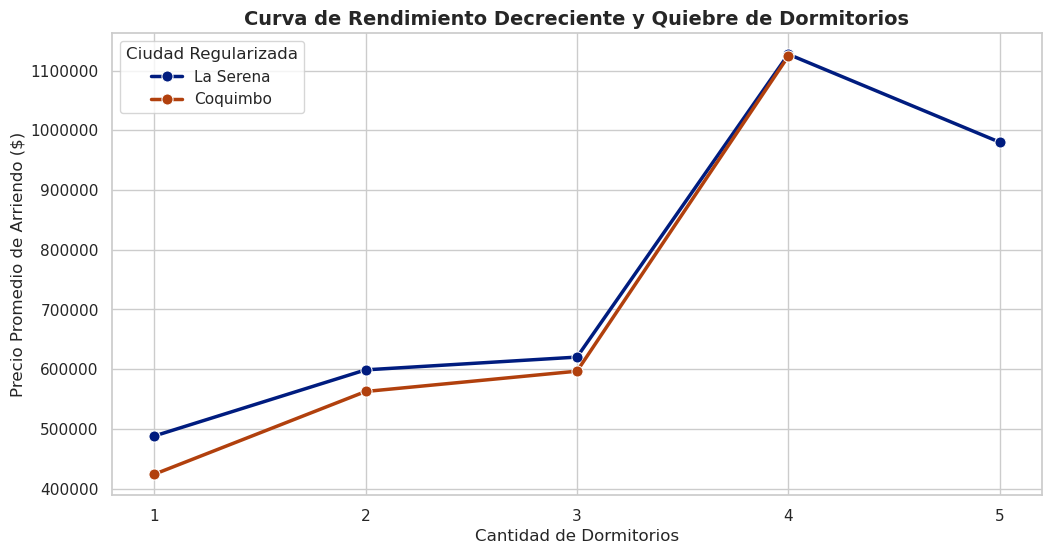

In [11]:
#Gráfico 2: Rendimiento Decreciente de los Dormitorios

plt.figure(figsize=(12, 6))
# Graficamos las curvas de rendimiento de ambas ciudades para contrastar
sns.lineplot(
    x='dormitorios_num', 
    y='precio_num', 
    hue='ciudad', 
    data=df_pandas_graficos, 
    marker='o', 
    linewidth=2.5,
    markersize=8,
    palette="dark",
    errorbar=None
)

plt.title("Curva de Rendimiento Decreciente y Quiebre de Dormitorios", fontsize=14, fontweight='bold')
plt.xlabel("Cantidad de Dormitorios", fontsize=12)
plt.ylabel("Precio Promedio de Arriendo ($)", fontsize=12)
plt.legend(title="Ciudad Regularizada")
plt.ticklabel_format(style='plain', axis='y')
plt.xticks([1, 2, 3, 4, 5])

plt.show()

Al proyectar la curva de rendimiento de los dormitorios en el gráfico, se evidencian algunos comportamientos:

EL Estancamiento (2 a 3 Dormitorios): Ambas curvas muestran una pendiente ascendente fuerte al pasar de 1 a 2 piezas. Sin embargo, al dar el salto hacia el tercer dormitorio, las líneas sufren un parón. En La Serena, agregar esta tercera habitación solo aporta un incremento marginal de $21.382 mensuales sobre el promedio, mientras que en Coquimbo el impacto es de $33.993. Esto demuestra que el formato de 3 dormitorios no genera un valor agregado real para el arrendatario común, estabilizando los precios regionales en torno a los $600.000.

El Quiebre (3 a 4 Dormitorios): Posterior al estancamiento, la dinámica del mercado cambia por completo. Las curvas experimentan un despegue vertical abrupto al alcanzar los 4 dormitorios, disparándose por sobre el $1.12 millones en ambas comunas. Este quiebre demuestra que la cuarta habitación rompe el estándar del departamento tradicional, marcando el ingreso a un nicho comercial exclusivo compuesto por casas amplias en sectores consolidados o plantas premium de baja rotación orientadas a un segmento socioeconómico alto.

En el negocio inmobiliario existe la falsa creencia de que "a más piezas, más caro lo cobro". Analizar esta curva es fundamental para no perder dinero construyendo metros cuadrados que el mercado no va a valorar. Si descubrimos dónde se estanca el precio (como vimos que pasa al pasar de 2 a 3 piezas), le estamos diciendo a un desarrollador: "No gastes dinero en hacer una tercera habitación, porque la gente te va a pagar casi lo mismo; invierte esos metros cuadrados en agrandar el living o la terraza". Nos ayuda a encontrar el tamaño eficiente para maximizar las ganancias. 


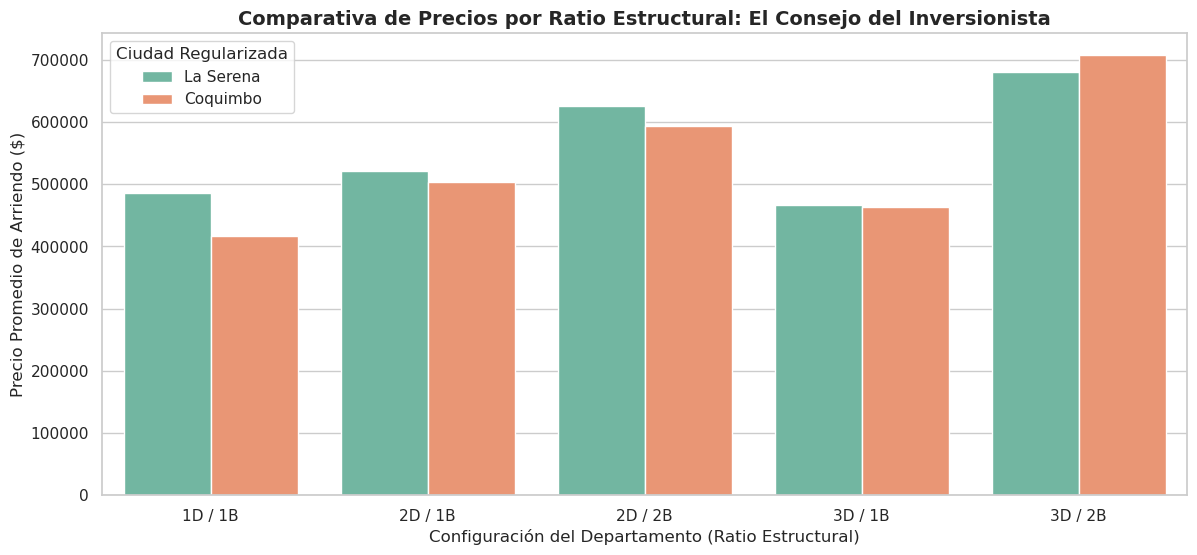

In [12]:

# GRÁFICO 3 - EL RATIO ÓPTIMO PARA EL INVERSIONISTA 

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos las configuraciones más importantes para que el gráfico no se sature

ratios_interes = ["1D / 1B", "2D / 1B", "2D / 2B", "3D / 1B", "3D / 2B"]
df_filtrado_ratios = df_pandas_graficos[df_pandas_graficos['ratio_config'].isin(ratios_interes)]

# 2. Configuración de la figura
plt.figure(figsize=(14, 6))

# 3. Crear el gráfico de barras comparativo por ciudad
sns.barplot(
    x='ratio_config', 
    y='precio_num', 
    hue='ciudad', 
    data=df_filtrado_ratios, 
    palette="Set2",
    errorbar=None,
    order=ratios_interes # Forzamos el orden lógico del mercado
)

# 4. Detalles estéticos y etiquetas limpias 
plt.title("Comparativa de Precios por Ratio Estructural: El Consejo del Inversionista", fontsize=14, fontweight='bold')
plt.xlabel("Configuración del Departamento (Ratio Estructural)", fontsize=12)
plt.ylabel("Precio Promedio de Arriendo ($)", fontsize=12)
plt.legend(title="Ciudad Regularizada")
plt.ticklabel_format(style='plain', axis='y') 

plt.show()

El gráfico de barras agrupadas permite contrastar directamente la eficiencia económica de las distintas configuraciones espaciales en la región, entregando tres hallazgos estratégicos clave para la toma de decisiones o inversión inmobiliaria:

- El Retorno del Segundo Baño 2D/1B vs. 2D/2B: Al comparar las tipologías de dos dormitorios, se observa una marcada diferencia visual en el tamaño de las barras a favor del formato con dos baños. En La Serena, un departamento 2D/1B promedia $521.040, mientras que un 2D/2B sube a $625.309 (una diferencia de $104.269 mensuales). En Coquimbo se replica la tendencia: el paso de un baño a dos bajo la misma cantidad de piezas incrementa el canon de $503.678 a $593.443 (+$89.765 mensuales). Estos datos demuestran que el mercado regional castiga el baño único; la diferencia paga rápidamente los costos constructivos del segundo baño y garantiza un Retorno de Inversión (ROI) mucho más atractivo.
- La Evidencia de la Obsolescencia Comercial 3D/1B: El fenómeno más impactante del gráfico es el desplome categórico de las barras correspondientes a tres dormitorios con un solo baño. En ambas ciudades, este ratio registra los valores más bajos de todo el estudio ($462.634 en Coquimbo y $465.897 en La Serena), quedando incluso por debajo de las tipologías de un solo ambiente 1D/1B. Esto demuestra científicamente que el déficit sanitario devalúa por completo las propiedades de mayor metraje; las familias actuales rechazan el hacinamiento de compartir un único baño entre tres habitaciones, por lo que un desarrollador o inversionista jamás debería construir bajo esta estructura.
- La Consolidación del Segmento Familiar 3D/2B: Al extremo derecho del gráfico, las barras de 3D/2B se consolidan como las más costosas del segmento residencial masivo, superando con comodidad la barrera de los $650.000 en ambas comunas ($680.148 en La Serena y $707.373 en Coquimbo). Al incorporar el segundo servicio higiénico a las tres habitaciones, el inmueble recupera de inmediato su atractivo comercial, posicionándose firmemente en el nicho familiar de ingresos estables y asegurando flujos de caja predecibles.

Analizar combinaciones como 2D/1B frente a 2D/2B es importante porque determina dónde rinde mejor el capital de trabajo. Les permite descubrir qué configuraciones garantizan un flujo de caja mensual más alto y, sobre todo, cuáles están quedando obsoletas (como el formato 3D/1B). Esto desde una perspectiva de un inversionista, le ayuda a prevenir cometer el error de comprar una propiedad barata que después nadie va a querer arrendar por ser incómoda. 

In [14]:
# PREGUNTA 4 - ÍNDICE DE DENSIDAD HABITACIONAL (DORMITORIOS / BAÑOS)

from pyspark.sql.functions import col, avg, count, round

# 1. Calculamos matemáticamente el Índice de Densidad Habitacional (IDH). Esto mide cuántos dormitorios dependen de cada baño de la propiedad

df_idh = df_con_ciudad_clasificada.withColumn(
    "IDH", 
    round(col("dormitorios_num") / col("banos_num"), 1)
)

print("======================================================================")
print("ANÁLISIS 4: EL IMPACTO DEL ÍNDICE DE DENSIDAD EN EL PRECIO REGIONAL")
print("======================================================================")
# Agrupamos por ciudad y por el índice matemático puro
df_idh_analisis = df_idh.groupBy("ciudad", "IDH") \
    .agg(
        round(avg("precio_num"), 0).alias("Precio_Promedio_CLP"),
        count("*").alias("Cantidad_Propiedades")
    ).filter(col("Cantidad_Propiedades") >= 10) \
    .orderBy("ciudad", "IDH")

df_idh_analisis.show(20, truncate=False)

ANÁLISIS 4: EL IMPACTO DEL ÍNDICE DE DENSIDAD EN EL PRECIO REGIONAL
+---------+---+-------------------+--------------------+
|ciudad   |IDH|Precio_Promedio_CLP|Cantidad_Propiedades|
+---------+---+-------------------+--------------------+
|Coquimbo |1.0|549801.0           |226                 |
|Coquimbo |1.3|1112727.0          |11                  |
|Coquimbo |1.5|707373.0           |118                 |
|Coquimbo |2.0|503678.0           |87                  |
|Coquimbo |3.0|462634.0           |93                  |
|La Serena|0.7|818182.0           |11                  |
|La Serena|1.0|602572.0           |632                 |
|La Serena|1.3|1110000.0          |10                  |
|La Serena|1.5|680148.0           |338                 |
|La Serena|2.0|524877.0           |203                 |
|La Serena|3.0|465897.0           |145                 |
+---------+---+-------------------+--------------------+



Análisis de Densidad Habitacional (IDH)

IDH = Dormitorios/Baños.Un IDH = 1.0 significa un equilibrio perfecto (ej: 1D/1B o 2D/2B). Cada pieza tiene su baño. Un IDH = 2.0 o 3.0 significa hacinamiento o "presión" sobre los servicios (ej: 2D/1B o 3D/1B). Hay muchas personas compitiendo por entrar al único baño de la propiedad.

Los datos demuestran una tendencia muy clara en la región: mientras más se satura el uso del baño en un departamento, menos valor tiene en el mercado y su precio cae de inmediato:

- El Castigo por Hacinamiento Sanitario (IDH de 1.0 a 3.0): Tanto en Coquimbo como en La Serena, a medida que el índice escala y se estresa el uso del servicio higiénico, el precio promedio se desploma de forma contundente. En La Serena, un equilibrio óptimo de 1.0 promedia $602.572 (con un volumen masivo de 632 activos); al pasar a una densidad de 2.0 el precio cae a $524.877, y al llegar al extremo de 3.0 colapsa hasta los $465.897. En Coquimbo se repite exactamente la misma curva descendente (1.0 -> $549.801; 2.0 -> $503.678; 3.0 -> $462.634). Esto comprueba científicamente que el mercado regional penaliza severamente los diseños de plantas que obligan a múltiples habitaciones a depender de un único baño, restándole competitividad comercial al activo. Los arrendatarios prefieren pagar una diferencia alta por garantizar privacidad familiar.
- El Aislamiento Matemático de la Alta Gama (IDH de 0.7 y 1.3):De manera interesante, el índice logra aislar con precisión matemática los nichos residenciales premium de la región. El valor IDH = 1.3 (que responde a la configuración de 4 dormitorios y 3 baños, 4D/3B) rompe por completo la tendencia y registra los promedios más altos de toda la muestra: $1.112.727 en Coquimbo y $1.110.000 en La Serena. Asimismo, en La Serena el valor IDH = 0.7 (2D/3B, donde hay un superávit de baños respecto a las piezas) promedia $818.182. Estos quiebres demuestran que cuando el diseño arquitectónico prioriza el espacio y la exclusividad sanitaria, el inmueble abandona el mercado masivo y califica de inmediato en el segmento residencial de lujo o alta gama.

Analizar la estructura interna de forma aislada (contar dormitorios o baños por separado) no siempre cuenta la historia completa del inmueble. Por esto, creamos de manera matemática la variable sintética IDH, que unifica ambos mundos para medir el nivel de confort higiénico o la "presión" real de uso sobre los baños de la propiedad. Estudiar este índice es fundamental para entender el comportamiento del consumidor moderno: nos permite comprobar con datos duros cómo el hacinamiento sanitario (muchas piezas dependiendo de un solo baño) destruye aceleradamente el valor de arriendo del activo. Además, funciona como un localizador estadístico perfecto para aislar los nichos exclusivos de alta gama y súper lujo, entregando directrices clave para que constructores e inversionistas diseñen plantas eficientes que respondan a la alta disposición a pagar por privacidad.

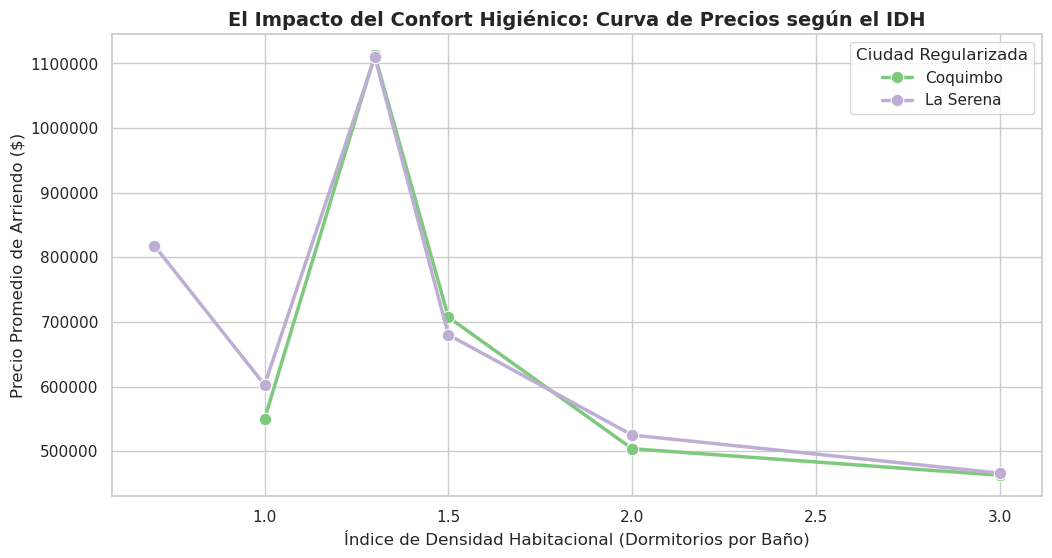

In [15]:

# GRÁFICO 4 - CURVA DE CASTIGO POR DENSIDAD HABITACIONAL (IDH)

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupamos los datos en Pandas para graficar los promedios limpios (filtramos muestras pequeñas)
df_agrupado_idh = df_pandas_graficos.groupby(['ciudad', 'IDH'])['precio_num'].mean().reset_index()
# Filtramos solo los IDH que aparecieron en la tabla limpia para evitar ruido
idh_validos = [0.7, 1.0, 1.3, 1.5, 2.0, 3.0]
df_agrupado_idh = df_agrupado_idh[df_agrupado_idh['IDH'].isin(idh_validos)]

# 2. Configuración de la figura
plt.figure(figsize=(12, 6))

# 3. Graficamos las líneas de tendencia por ciudad
sns.lineplot(
    x='IDH', 
    y='precio_num', 
    hue='ciudad', 
    data=df_agrupado_idh, 
    marker='o', 
    linewidth=2.5,
    markersize=9,
    palette="Accent" 
)

# 4. Detalles estéticos 
plt.title("El Impacto del Confort Higiénico: Curva de Precios según el IDH", fontsize=14, fontweight='bold')
plt.xlabel("Índice de Densidad Habitacional (Dormitorios por Baño)", fontsize=12)
plt.ylabel("Precio Promedio de Arriendo ($)", fontsize=12)
plt.legend(title="Ciudad Regularizada")
plt.ticklabel_format(style='plain', axis='y') 

plt.show()

El Gráfico plasma súper claro la dinámica del Índice de Densidad Habitacional (IDH) en la región. Al analizar el comportamiento de las curvas, destacan dos realidades comerciales muy potentes:
- La Caída por Saturación Sanitaria (IDH 1.0 -> 2.0 -> 3.0): Se aprecia una tendencia hacia abajo muy marcada a partir del equilibrio perfecto (1.0). Esto muestra de manera directa cómo el mercado castiga el precio de los arriendos a medida que más dormitorios dependen de un solo baño. Cuando la relación pasa a 2 o 3 piezas por baño, el valor se va directo al piso del mercado regional (en torno a los $462.000 en Coquimbo y $465.000 en La Serena), demostrando que las familias están dispuestas a pagar más por no tener que competir por el uso del baño diario.
- Los espacios exclusivos de alta gama (IDH 0.7 y 1.3): Por otro lado, el gráfico expone con éxito dos puntos que se escapan por completo del mercado común. Primero, el punto de máximo confort exclusivo en La Serena en el IDH = 0.7 (departamentos con más baños que piezas). Segundo, el impresionante pico hacia arriba en el IDH = 1.3 en ambas comunas. Este punto funciona como un verdadero localizador matemático del segmento de lujo en la zona (las plantas de 4 dormitorios y 3 baños), donde los precios rompen el techo y se disparan por sobre el $1.1 millones mensuales debido a su amplitud y exclusividad.